<a href="https://colab.research.google.com/github/elizafhilip-png/TugasDataMining/blob/main/Tugas%20Minggu%20Ke%20Enam/2304020183_Eliza%20Fhilip%20Sandjaya_Tugas%20Data%20Mining%204.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [62]:
# ================================
# KLASIFIKASI DATA TITANIC
# ================================

# 1. Import Library
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier

Pada tahap ini saya mengimpor library yang dibutuhkan untuk analisis data dan machine learning.

* pandas & numpy → untuk pengolahan data
* matplotlib & seaborn → untuk visualisasi
* sklearn → untuk pembuatan model klasifikasi dan evaluasi

In [61]:
# 2. Upload & Load Data
from google.colab import files
uploaded = files.upload()

uploaded_filename = list(uploaded.keys())[0]
df = pd.read_csv(uploaded_filename)

Saving titanic_dataset.csv to titanic_dataset (14).csv


Dataset Titanic diunggah ke Google Colab, kemudian dibaca menggunakan pandas menjadi dataframe agar bisa diolah lebih lanjut.

In [63]:
# 3. Amankan Nama Kolom
df.columns = df.columns.str.strip()
df.columns = df.columns.str.lower()

print("Kolom dataset:")
print(df.columns)

Kolom dataset:
Index(['passengerid', 'survived', 'pclass', 'name', 'sex', 'age', 'sibsp',
       'parch', 'ticket', 'fare', 'cabin', 'embarked'],
      dtype='object')


Nama kolom dibersihkan dengan menghilangkan spasi dan mengubah menjadi huruf kecil agar konsisten dan menghindari error saat pemanggilan kolom.

In [64]:
# 4. Eksplorasi Data
print("\nData Awal:")
print(df.head())

print("\nInfo Data:")
print(df.info())

print("\n=== Statistik Data ===")
print(df.describe())

print("\nMissing Value:")
print(df.isnull().sum())


Data Awal:
   passengerid  survived  pclass  \
0            1         0       3   
1            2         1       1   
2            3         1       3   
3            4         1       1   
4            5         0       3   

                                                name     sex   age  sibsp  \
0                            Braund, Mr. Owen Harris    male  22.0      1   
1  Cumings, Mrs. John Bradley (Florence Briggs Th...  female  38.0      1   
2                             Heikkinen, Miss. Laina  female  26.0      0   
3       Futrelle, Mrs. Jacques Heath (Lily May Peel)  female  35.0      1   
4                           Allen, Mr. William Henry    male  35.0      0   

   parch            ticket     fare cabin embarked  
0      0         A/5 21171   7.2500   NaN        S  
1      0          PC 17599  71.2833   C85        C  
2      0  STON/O2. 3101282   7.9250   NaN        S  
3      0            113803  53.1000  C123        S  
4      0            373450   8.0500   NaN  

Pada tahap ini dilakukan:

* Melihat beberapa data awal (head)
* Mengetahui struktur data (info)
* Mengecek missing value

Tujuannya untuk memahami kondisi dataset sebelum diproses.

In [66]:
# 5. Data Preprocessing
# Hapus kolom yang tidak penting
df = df.drop(['passengerid','name', 'ticket', 'cabin'], axis=1, errors='ignore')

# Isi missing value
df['age'] = df['age'].fillna(df['age'].median())
df['embarked'] = df['embarked'].fillna(df['embarked'].mode()[0])

# Encode kategori
le = LabelEncoder()
df['sex'] = le.fit_transform(df['sex'])
df['embarked'] = le.fit_transform(df['embarked'])


Tahap ini bertujuan untuk membersihkan dan menyiapkan data:

* Menghapus kolom yang tidak relevan seperti name, ticket, cabin
* Mengisi missing value:
  * age → dengan median
  * embarked → dengan modus
* Mengubah data kategorik menjadi numerik:
  * sex dan embarked → menggunakan Label Encoding

Agar data bisa digunakan oleh model machine learning.

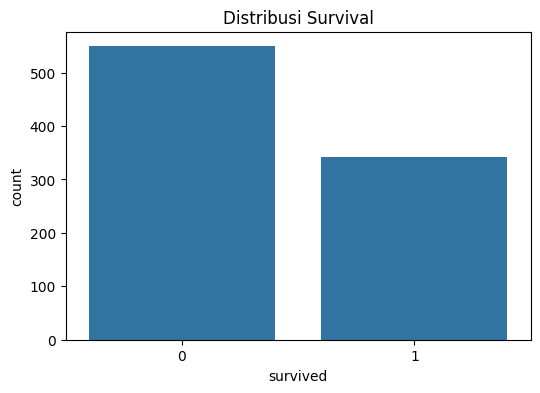

In [67]:
# 6. Visualisasi
plt.figure(figsize=(6,4))
sns.countplot(x='survived', data=df)
plt.title("Distribusi Survival")
plt.show()

Menampilkan grafik distribusi penumpang yang selamat dan tidak selamat.
Tujuannya untuk melihat keseimbangan data target.

In [69]:
# 7. Split Data
X = df.drop('survived', axis=1)
y = df['survived']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

Data dibagi menjadi:

* Data training (80%) → untuk melatih model
* Data testing (20%) → untuk menguji model

Agar performa model bisa dievaluasi secara objektif.

In [70]:
# 8. Normalisasi
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

Data dinormalisasi menggunakan StandardScaler agar memiliki skala yang sama.
Hal ini penting terutama untuk algoritma tertentu agar performa lebih optimal.

In [71]:
# 9. Model 1 : Random Forest
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)

rf_pred = rf_model.predict(X_test)

Random Forest digunakan sebagai model utama karena:

* Lebih akurat
* Menggabungkan banyak decision tree
* Mengurangi overfitting

Model dilatih menggunakan data training.

In [72]:
# 10. Model 2 : Decision Tree
dt_model = DecisionTreeClassifier(random_state=42)
dt_model.fit(X_train_scaled, y_train)

dt_pred = dt_model.predict(X_test_scaled)

Decision Tree digunakan sebagai pembanding.
Model ini lebih sederhana dan mudah dipahami, tetapi biasanya kurang stabil dibanding Random Forest.

In [73]:
# 11. Evaluasi Random Forest
print("\n===== RANDOM FOREST =====")
print("Akurasi:", accuracy_score(y_test, rf_pred))
print("\nConfusion Matrix:")
print(confusion_matrix(y_test, rf_pred))
print("\nClassification Report:")
print(classification_report(y_test, rf_pred))


===== RANDOM FOREST =====
Akurasi: 0.8212290502793296

Confusion Matrix:
[[92 13]
 [19 55]]

Classification Report:
              precision    recall  f1-score   support

           0       0.83      0.88      0.85       105
           1       0.81      0.74      0.77        74

    accuracy                           0.82       179
   macro avg       0.82      0.81      0.81       179
weighted avg       0.82      0.82      0.82       179



Model dievaluasi menggunakan:

* Accuracy → tingkat ketepatan prediksi
* Confusion Matrix → perbandingan prediksi vs data asli
* Classification Report → precision, recall, dan f1-score

In [74]:
# 12. Evaluasi Decision Tree
print("\n===== DECISION TREE =====")
print("Akurasi:", accuracy_score(y_test, dt_pred))
print("\nConfusion Matrix:")
print(confusion_matrix(y_test, dt_pred))
print("\nClassification Report:")
print(classification_report(y_test, dt_pred))


===== DECISION TREE =====
Akurasi: 0.7821229050279329

Confusion Matrix:
[[83 22]
 [17 57]]

Classification Report:
              precision    recall  f1-score   support

           0       0.83      0.79      0.81       105
           1       0.72      0.77      0.75        74

    accuracy                           0.78       179
   macro avg       0.78      0.78      0.78       179
weighted avg       0.79      0.78      0.78       179



Evaluasi dilakukan sama seperti Random Forest untuk membandingkan performa kedua model.

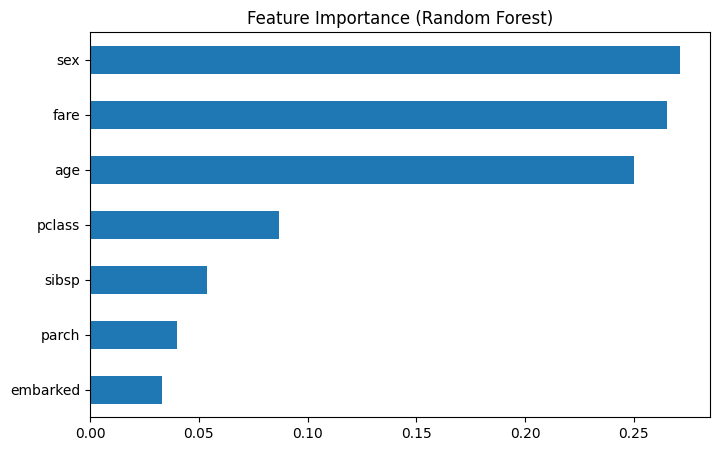

In [75]:
# 13. Feature Importance
importances = pd.Series(rf_model.feature_importances_, index=X.columns)
importances.sort_values().plot(kind='barh', figsize=(8,5))
plt.title("Feature Importance (Random Forest)")
plt.show()

Menampilkan fitur yang paling berpengaruh terhadap prediksi.
Misalnya:
* sex
* pclass
* age

Ini membantu memahami faktor yang mempengaruhi keselamatan penumpang.